# **Business Case Study: Decision Tree vs Random Forest**
## Predicting Customer Churn for a Telecom Company (Previous case context)

---

**Business Problem:** A telecom company is experiencing customer attrition and wants to proactively
identify customers likely to churn, so retention teams can intervene before they leave.

**Objective:** Train and compare two supervised classification models — a Decision Tree and a
Random Forest — then tune both with hyperparameter search, and extract interpretability signals
through feature and permutation importance.

**Dataset:** 2,000 telecom customers with 10 business-relevant features.
---


## **Setup**

In [ ]:

# Provides multi-dimensional array objects and fast numerical operations. It's the foundation for scientific computing in Python, offering vectorized math,
# linear algebra, Fourier transforms, and random number generation.
import numpy as np

# Built on NumPy, it supplies high-performance, easy-to-use data structures like Series (1D) and DataFrame (2D) for data manipulation, cleaning, and analysis.
# Key features include handling missing data, merging/grouping, and time series functionality.
import pandas as pd

# A comprehensive plotting library for creating static, animated, or interactive visualizations. It offers fine-grained control over charts, graphs, and figures,
# making it ideal for custom plots, histograms, scatter plots, and subplots.
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Split data into training and testing sets.
from sklearn.model_selection import train_test_split

# Hyperparameter tuning with cross-validation (See class).
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

# Tree-based models. Note the difference between "tree" and "ensemble"
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# auxiliary function to plot a tree
from sklearn.tree import plot_tree

# metric functions for classification models
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, accuracy_score,
                              ConfusionMatrixDisplay)

# permutation importance function
from sklearn.inspection import permutation_importance


## **Dataset — Telecom Churn**



In [ ]:
# Read data
df = pd.read_csv('telecom_churn.csv')
df.head()


,Monthly_Charges,Tenure_Months,Num_Support_Calls,Contract_Type,Internet_Speed,Add_On_Services,Payment_Delay,Data_Usage_GB,Family_Plan,Satisfaction_Score,Churn
0,-1.681695,-2.045293,1.489906,3.117893,-1.703133,0.006515,0.389102,0.423369,-0.456080,-0.052814,1
1,-0.790052,3.117627,0.591676,2.401760,-0.507517,2.275051,-1.711899,-1.668736,-4.060853,2.250830,0
2,1.510215,0.233320,-0.853680,-3.605998,-3.089854,0.827876,1.198214,-0.515310,3.038436,2.539143,0
3,2.936748,0.686779,-0.500167,-1.844812,-0.078749,-0.385536,-0.757990,-0.856712,-0.834145,0.558070,0
4,0.147925,-1.211220,-0.080717,1.981902,-2.626695,1.692638,-1.133017,1.216284,0.555418,0.695331,0


In [ ]:
# Explore the class imbalance
df.Churn.value_counts()

,count
Churn,
0,1378
1,622


In [ ]:
# Explore the correlations
df.corr()

,Monthly_Charges,Tenure_Months,Num_Support_Calls,Contract_Type,Internet_Speed,Add_On_Services,Payment_Delay,Data_Usage_GB,Family_Plan,Satisfaction_Score,Churn
Monthly_Charges,1.000000,0.332572,-0.007867,-0.644712,0.172556,-0.072387,-0.143855,-0.287713,0.295453,0.099785,-0.271871
Tenure_Months,0.332572,1.000000,-0.053545,-0.744193,0.437335,0.483917,-0.271392,-0.601868,0.300477,0.448394,-0.311167
Num_Support_Calls,-0.007867,-0.053545,1.000000,0.034745,-0.041069,-0.042759,0.002264,0.008719,-0.003309,-0.038140,0.026604
Contract_Type,-0.644712,-0.744193,0.034745,1.000000,-0.375316,-0.133391,-0.144480,0.560636,-0.661381,-0.314078,0.101316
Internet_Speed,0.172556,0.437335,-0.041069,-0.375316,1.000000,-0.182774,-0.150138,-0.007296,0.041111,0.010194,-0.004287
Add_On_Services,-0.072387,0.483917,-0.042759,-0.133391,-0.182774,1.000000,-0.108075,-0.141987,0.049659,0.222379,-0.276383
Payment_Delay,-0.143855,-0.271392,0.002264,-0.144480,-0.150138,-0.108075,1.000000,-0.167156,0.048105,-0.130077,0.486493
Data_Usage_GB,-0.287713,-0.601868,0.008719,0.560636,-0.007296,-0.141987,-0.167156,1.000000,-0.058974,0.037425,0.019133
Family_Plan,0.295453,0.300477,-0.003309,-0.661381,0.041111,0.049659,0.048105,-0.058974,1.000000,0.136202,-0.011882
Satisfaction_Score,0.099785,0.448394,-0.038140,-0.314078,0.010194,0.222379,-0.130077,0.037425,0.136202,1.000000,-0.256099


## **Decision Tree — Baseline (no tuning)**

Before any hyperparameter search we fit a default Decision Tree to establish a
performance baseline. Default trees tend to **overfit** (unlimited depth).


In [ ]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=["Churn"]), df["Churn"],
    test_size=0.3, random_state=42, stratify=df["Churn"]
)

# Construct the decision tree
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)


# Get the prediction metrics
dt_base_pred  = dt_base.predict(X_test)
dt_base_proba = dt_base.predict_proba(X_test)[:, 1]
dt_base_acc   = accuracy_score(y_test, dt_base_pred)
dt_base_auc   = roc_auc_score(y_test, dt_base_proba)

print(f"Decision Tree (baseline)")
print(f"  Max depth  : {dt_base.get_depth()}")
print(f"  Accuracy   : {dt_base_acc:.4f}")
print(f"  ROC-AUC    : {dt_base_auc:.4f}")


Decision Tree (baseline)
  Max depth  : 20
  Accuracy   : 0.8483
  ROC-AUC    : 0.8152


## 3 · Decision Tree — GridSearchCV

We perform an exhaustive grid over **3 hyperparameters**:

| Parameter | Values |
|---|---|
| `max_depth` | 3, 5, 7, 10, None |
| `min_samples_split` | 2, 5, 10 |


In [ ]:
dt_grid_params = {
    "max_depth":         [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
}

dt_gs = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_grid_params, cv=5, scoring="roc_auc", n_jobs=-1, verbose=0
)
dt_gs.fit(X_train, y_train)

dt_best  = dt_gs.best_estimator_
dt_pred  = dt_best.predict(X_test)
dt_proba = dt_best.predict_proba(X_test)[:, 1]
dt_acc   = accuracy_score(y_test, dt_pred)
dt_auc   = roc_auc_score(y_test, dt_proba)

print(f"Best params : {dt_gs.best_params_}")
print(f"Accuracy    : {dt_acc:.4f}  (baseline: {dt_base_acc:.4f})")
print(f"ROC-AUC     : {dt_auc:.4f}  (baseline: {dt_base_auc:.4f})")


Best params : {'max_depth': 5, 'min_samples_split': 10}
Accuracy    : 0.7950  (baseline: 0.8483)
ROC-AUC     : 0.8283  (baseline: 0.8152)


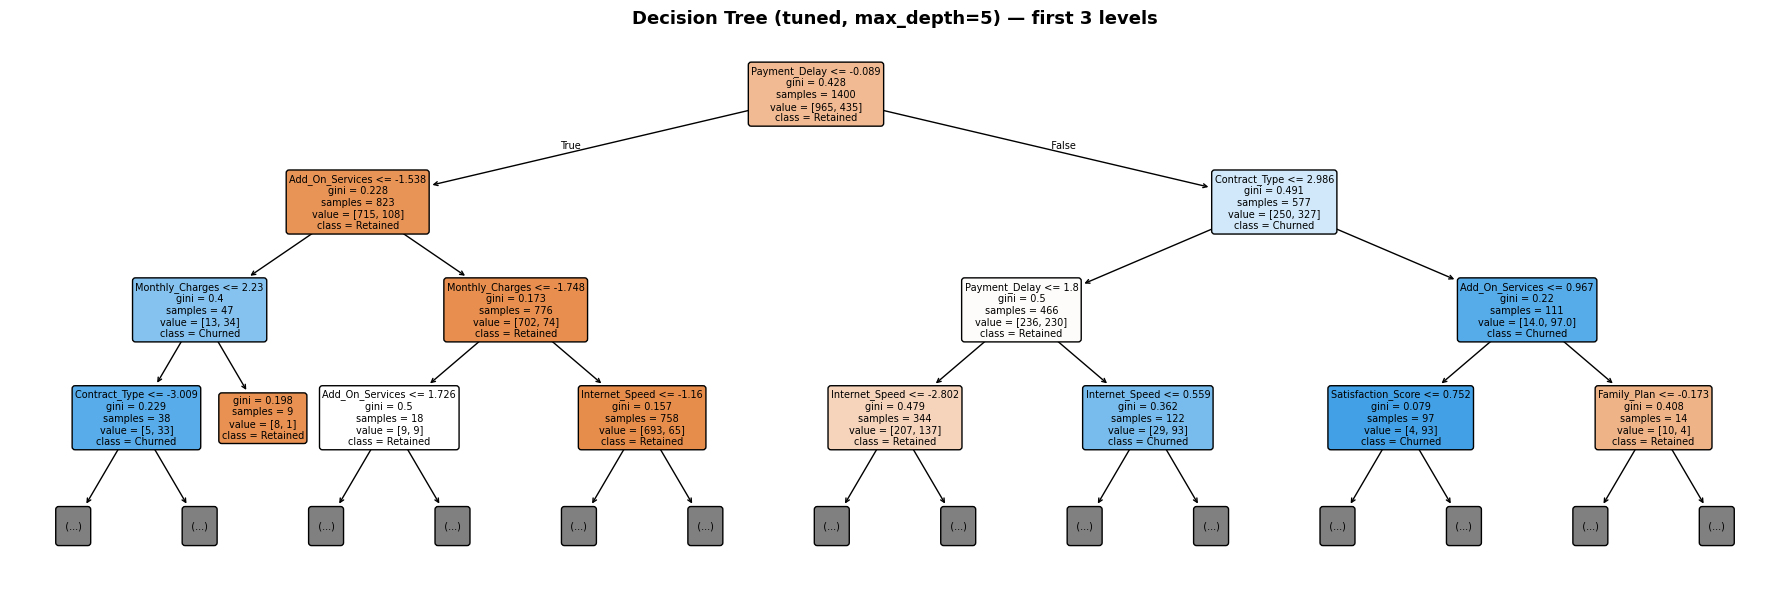

In [ ]:
# Visualise the pruned tree
fig, ax = plt.subplots(figsize=(18, 6))
feature_names = X_train.columns
plot_tree(dt_best, feature_names=feature_names,
          class_names=["Retained", "Churned"],
          filled=True, rounded=True, max_depth=3,
          fontsize=7, ax=ax,
          impurity=True, proportion=False)
ax.set_title(f"Decision Tree (tuned, max_depth={dt_best.max_depth}) — first 3 levels", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout(); plt.show()


## **Random Forest — RandomizedSearch → GridSearchCV**

A two-stage strategy is used for the Random Forest:

1. **RandomizedSearchCV** (20 iterations) over a broad space to cheaply identify a promising region.
2. **GridSearchCV** with a narrow grid centred on the best random-search result for fine-grained tuning.

Both searches cover **3 hyperparameters**:

| Parameter | Description |
|---|---|
| `n_estimators` | Number of trees in the forest |
| `max_depth` | Maximum depth per tree |
| `max_features` | Features considered at each split |


In [ ]:
# ── Stage 1: RandomizedSearchCV ──────────────────────────────
rf_rand_params = {
    "n_estimators": [50, 100, 200, 300],
    "max_depth":    [None, 5, 10, 20],
    "max_features": ["sqrt", "log2", 0.5],
}
rf_rs = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    rf_rand_params, n_iter=20, cv=5,
    scoring="roc_auc", n_jobs=-1, random_state=42
)
rf_rs.fit(X_train, y_train)
print(f"RandomSearch best  : {rf_rs.best_params_}  →  AUC={rf_rs.best_score_:.4f}")


RandomSearch best  : {'n_estimators': 300, 'max_features': 'sqrt', 'max_depth': None}  →  AUC=0.9386


In [ ]:
# ── Stage 2: GridSearchCV (narrow) ───────────────────────────
best_n  = rf_rs.best_params_["n_estimators"]
best_d  = rf_rs.best_params_["max_depth"]
best_mf = rf_rs.best_params_["max_features"]

n_range  = sorted({max(50, best_n - 50), best_n, best_n + 50})
d_range  = [best_d] if best_d is None else sorted({max(3, best_d - 3), best_d, best_d + 3})
mf_range = sorted({best_mf, "sqrt"}, key=str)

rf_grid_params = {
    "n_estimators": n_range,
    "max_depth":    d_range,
    "max_features": mf_range,
}
rf_gs = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_grid_params, cv=5, scoring="roc_auc", n_jobs=-1
)
rf_gs.fit(X_train, y_train)

rf_best  = rf_gs.best_estimator_
rf_pred  = rf_best.predict(X_test)
rf_proba = rf_best.predict_proba(X_test)[:, 1]
rf_acc   = accuracy_score(y_test, rf_pred)
rf_auc   = roc_auc_score(y_test, rf_proba)

print(f"GridSearch best    : {rf_gs.best_params_}  →  AUC={rf_gs.best_score_:.4f}")
print(f"\nTest Accuracy  : {rf_acc:.4f}")
print(f"Test ROC-AUC   : {rf_auc:.4f}")


GridSearch best    : {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 350}  →  AUC=0.9388

Test Accuracy  : 0.8900
Test ROC-AUC   : 0.9333


## **Feature Importance**

### **Built-in (MDI) — Decision Tree vs Random Forest**

Mean Decrease in Impurity: how much each feature reduces weighted node impurity across all splits.

> ⚠️ MDI can be **biased toward high-cardinality features**. Use permutation importance as a sanity check.


In [ ]:
dt_fi = pd.Series(dt_best.feature_importances_, index=feature_names)
rf_fi = pd.Series(rf_best.feature_importances_, index=feature_names)

summary = pd.DataFrame({
    "DT": dt_fi,
    "RF": rf_fi,
})
summary


,DT,RF
Monthly_Charges,0.048330,0.127936
Tenure_Months,0.005733,0.093579
Num_Support_Calls,0.000000,0.037355
Contract_Type,0.103026,0.068161
Internet_Speed,0.099478,0.086958
Add_On_Services,0.163235,0.131845
Payment_Delay,0.498560,0.245659
Data_Usage_GB,0.000000,0.056989
Family_Plan,0.068758,0.068748
Satisfaction_Score,0.012882,0.082770


### **Permutation Importance — Random Forest**

Permutation importance measures how much model accuracy drops when a feature's values are randomly shuffled.
This is **model-agnostic** and reflects real predictive power on the test set.


In [ ]:
perm = permutation_importance(
    rf_best, X_test, y_test,
    n_repeats=20, random_state=42, n_jobs=-1
)
perm_fi  = pd.Series(perm.importances_mean, index=feature_names).sort_values()
perm_std = pd.Series(perm.importances_std,  index=feature_names).reindex(perm_fi.index)

summary = pd.DataFrame({
    "Mean": perm_fi,
    "Std":  perm_std,
})
summary

,Mean,Std
Num_Support_Calls,-0.002750,0.003700
Tenure_Months,0.006000,0.004062
Data_Usage_GB,0.006500,0.004246
Contract_Type,0.007833,0.004052
Satisfaction_Score,0.022417,0.005737
Family_Plan,0.028417,0.004609
Internet_Speed,0.029417,0.006714
Monthly_Charges,0.042917,0.007262
Add_On_Services,0.068250,0.010348
Payment_Delay,0.118667,0.013130


## **Classification Reports**

In [ ]:
print("=" * 50)
print("  DECISION TREE (tuned)")
print("=" * 50)
print(classification_report(y_test, dt_pred, target_names=["Retained", "Churned"]))

print("=" * 50)
print("  RANDOM FOREST (tuned)")
print("=" * 50)
print(classification_report(y_test, rf_pred, target_names=["Retained", "Churned"]))


  DECISION TREE (tuned)
              precision    recall  f1-score   support

    Retained       0.86      0.84      0.85       413
     Churned       0.66      0.70      0.68       187

    accuracy                           0.80       600
   macro avg       0.76      0.77      0.76       600
weighted avg       0.80      0.80      0.80       600

  RANDOM FOREST (tuned)
              precision    recall  f1-score   support

    Retained       0.88      0.97      0.92       413
     Churned       0.91      0.72      0.80       187

    accuracy                           0.89       600
   macro avg       0.90      0.84      0.86       600
weighted avg       0.89      0.89      0.89       600

